# Make DBs from data in SQLite

In [1]:
import sqlite3
import json
from tqdm import tqdm
import os
import gzip
import numpy as np
import pandas as pd

In [2]:
def load_data(file_name, head = 500):
    count = 0
    data = []
    with gzip.open(file_name) as fin:
        for l in fin:
            d = json.loads(l)
            count += 1
            data.append(d)
            
            # break if reaches the 100th line
            if (head is not None) and (count > head):
                break
    return data

In [3]:
DIR = './complete'
books = load_data(os.path.join(DIR, 'goodreads_books.json.gz'))

In [4]:
display(np.random.choice(books))

{'isbn': '0671015311',
 'text_reviews_count': '126',
 'series': ['161229'],
 'country_code': 'US',
 'language_code': 'eng',
 'popular_shelves': [{'count': '1607', 'name': 'to-read'},
  {'count': '164', 'name': 'mystery'},
  {'count': '136', 'name': 'historical-fiction'},
  {'count': '41', 'name': 'historical'},
  {'count': '40', 'name': 'fiction'},
  {'count': '33', 'name': 'historical-mystery'},
  {'count': '25', 'name': 'series'},
  {'count': '24', 'name': 'mysteries'},
  {'count': '16', 'name': 'currently-reading'},
  {'count': '15', 'name': 'tudor'},
  {'count': '14', 'name': 'audiobook'},
  {'count': '14', 'name': 'england'},
  {'count': '13', 'name': 'historical-mysteries'},
  {'count': '10', 'name': 'owned'},
  {'count': '9', 'name': 'crime'},
  {'count': '9', 'name': '16th-century'},
  {'count': '8', 'name': 'first-in-series'},
  {'count': '8', 'name': 'ursula-blanchard'},
  {'count': '7', 'name': 'mystery-thriller'},
  {'count': '7', 'name': 'audio'},
  {'count': '7', 'name': 

In [5]:
DIR = './byGenre'
rom = load_data(os.path.join(DIR, 'goodreads_books_romance.json.gz'))
display(np.random.choice(rom))

{'isbn': '',
 'text_reviews_count': '14',
 'series': [],
 'country_code': 'US',
 'language_code': 'en-US',
 'popular_shelves': [{'count': '340', 'name': 'to-read'},
  {'count': '11', 'name': 'fantasy'},
  {'count': '5', 'name': 'romance'},
  {'count': '2', 'name': 'maybe'},
  {'count': '2', 'name': 'kindle'},
  {'count': '1', 'name': 'not-have'},
  {'count': '1', 'name': 'fantasy-sfy'},
  {'count': '1', 'name': 'to-read-novels'},
  {'count': '1', 'name': 'not-at-the-library'},
  {'count': '1', 'name': 'nope'},
  {'count': '1', 'name': 'new-books'},
  {'count': '1', 'name': 'amazon-recs'},
  {'count': '1', 'name': 'antecámara'},
  {'count': '1', 'name': 'adventure-action'},
  {'count': '1', 'name': 'to-buy'},
  {'count': '1', 'name': 'must-read-soon'},
  {'count': '1', 'name': 'awesome-cover'},
  {'count': '1', 'name': 'high-fantasy'},
  {'count': '1', 'name': 'young-adult'},
  {'count': '1', 'name': 'romance-3'},
  {'count': '1', 'name': 'witches-or-druids'},
  {'count': '1', 'name': '

In [37]:
b = np.random.choice(rom)
for author in b['authors']:
    print(author['author_id'])

47231


In [6]:
DIR = './byGenre'
rom = load_data(os.path.join(DIR, 'goodreads_reviews_romance.json.gz'))
display(np.random.choice(rom))

{'user_id': '01ec1a320ffded6b2dd47833f2c8e4fb',
 'book_id': '35275234',
 'review_id': '4c7feecc438639b41c45ae4b8e7ae97c',
 'rating': 4,
 'review_text': "3.5 - 4 stars \n Beautiful and poignant yet very violent spin-off from the Nine Minutes series. Lots of unexpected twists and turns! \n I loved the storyline and the originality of the plot. Even though I was familiar with Anthony Bear and Christy from the Nine Minutes series, this book really explored their relationship and Anthony's early life. \n I could not WAIT for this book to come out since Beth Flynn is a very special and talented writer. The Nine Minutes Series is one of my all-time FAVORITE biker romances and I recommend it to anyone who will listen! \n Anthony is a fighter. Faced with racism from a young age, he clawed his way to the top and created one of the most feared and most successful illegal businesses on the West Coast of Florida. He is Boss. When a large debt is owed to him, he sets out to collect. \n He kidnaps th

In [31]:
DIR = './byGenre'
romi = load_data(os.path.join(DIR, 'goodreads_interactions_romance.json.gz'))
df = pd.DataFrame(romi)

In [36]:
df[df['rating'] > 0]

,user_id,book_id,review_id,is_read,rating,review_text_incomplete,date_added,date_updated,read_at,started_at
7,8842281e1d1347389f2ab93d60773d4d,18135,d0aa055c0b0a5b0c4f13f9d358d51cd9,True,4,,Tue Jun 19 00:40:24 -0700 2007,Wed Mar 22 11:45:33 -0700 2017,,
8,8842281e1d1347389f2ab93d60773d4d,1893,5347a776a1703b823ce029d68ae98275,True,5,So the other day Elizabeth and I are in the bo...,Tue Oct 10 19:08:05 -0700 2006,Sun Feb 19 02:04:48 -0800 2017,Sun Oct 01 00:00:00 -0700 2006,
9,72fb0d0087d28c832f15776b0d936598,17939501,719711cc71eec0bb54d2d97322c0e11b,True,5,"It is very hard to believe this is all true, b...",Fri Nov 08 20:17:30 -0800 2013,Fri Nov 08 20:22:59 -0800 2013,,
10,72fb0d0087d28c832f15776b0d936598,15706923,6a870a66f732183b60214d57fa553093,True,2,Ehhhhhh.<br /><br />Really nothing to rave abo...,Fri Nov 08 20:14:53 -0800 2013,Fri Nov 08 20:16:50 -0800 2013,,
11,72fb0d0087d28c832f15776b0d936598,7840190,f73a70f64564d4a8f4cfb2d2e9d5836f,True,4,Enjoyable read! I liked that Connie is not a t...,Fri Nov 08 19:57:47 -0800 2013,Fri Nov 08 20:01:41 -0800 2013,,
12,72fb0d0087d28c832f15776b0d936598,15463724,547aeff3c7ee5b4a39a93cd2a720b001,True,4,There are definitely too many books lately wit...,Wed Oct 30 11:19:32 -0700 2013,Wed Oct 30 11:20:53 -0700 2013,,
13,72fb0d0087d28c832f15776b0d936598,2718668,768e4a82b89e36055706857e9268b8e9,True,5,I really enjoyed this book! Chick lit with bra...,Wed Oct 30 11:13:28 -0700 2013,Wed Oct 30 11:14:16 -0700 2013,,
14,72fb0d0087d28c832f15776b0d936598,1885,11beb5d3be4ebe9983ffa224b968dd17,True,5,,Mon Jun 04 19:01:18 -0700 2012,Mon Jun 04 19:01:18 -0700 2012,,
18,ab2923b738ea3082f5f3efcbbfacb218,47401,303e3bb8890afde2b3849e9c1ebeaafe,True,4,,Wed Nov 11 12:45:11 -0800 2009,Wed Nov 11 12:45:11 -0800 2009,,
19,ab2923b738ea3082f5f3efcbbfacb218,227443,fa6ede0afb0a5e0b4d7b78855f81d8ed,True,3,,Tue Nov 10 17:22:41 -0800 2009,Tue Nov 10 17:22:41 -0800 2009,,


In [1]:
# open romance.db in sqlite3
conn = sqlite3.connect("byGenre/romance.db")
cursor = conn.cursor()

In [2]:
# create books table 
cursor.execute("""
CREATE TABLE books (
    book_id TEXT PRIMARY KEY,
    title TEXT,
    average_rating REAL,
    ratings_count INTEGER
)
""")

In [5]:
# create reviews table 
cursor.execute("""
CREATE TABLE reviews (
    book_id TEXT PRIMARY KEY,
    rating REAL,
    review_text TEXT
)
""")

In [7]:
# Functions for loading books and reviews into the database 

def load_json_books(path):
    data = []
    with gzip.open(path, "rt") as f:
        for i, line in enumerate(tqdm(f)):
            book = json.loads(line)
    
            cursor.execute("""
                INSERT OR IGNORE INTO books
                VALUES (?, ?, ?, ?)
            """, (
                book["book_id"],
                book["title"],
                float(book["average_rating"]),
                int(book["ratings_count"])
            ))
            if i % 5000 == 0:
                conn.commit()
    conn.commit()

def load_json_reviews(path):
    data = []
    with gzip.open(path, "rt") as f:
        for i, line in enumerate(tqdm(f)):
            rev = json.loads(line)
    
            cursor.execute("""
                INSERT OR IGNORE INTO reviews
                VALUES (?, ?, ?)
            """, (
                rev["book_id"],
                float(rev["rating"]),
                rev["review_text"]
            ))
            if i % 5000 == 0:
                conn.commit()
    conn.commit()

In [13]:
DIR_GENRE = './byGenre/'

In [14]:
load_json_books(os.path.join(DIR_GENRE, "goodreads_books_romance.json.gz"))

335449it [00:23, 14290.74it/s]


In [15]:
load_json_reviews(os.path.join(DIR_GENRE, "goodreads_reviews_romance.json.gz"))

3565378it [01:07, 52778.32it/s]


In [38]:
# test saving SQL query results into pandas
df = pd.read_sql_query(
    "SELECT * FROM books",
    conn
)

df.head()

,book_id,title,average_rating,ratings_count
0,34883016,Playmaker: A Venom Series Novella,3.86,5
1,29074693,"Prowled Darkness (Dante's Circle, #7)",4.23,149
2,3209316,Emma,3.99,42
3,30838933,"Guardian Cougar (Finding Fatherhood, #2)",4.31,139
4,27419760,Wedding Girl,3.98,167


In [21]:
# Check that all books were loaded in
len(df['book_id'])

335449

In [24]:
# View the top rated books sorted first by avg ratings then by number of ratings (descending)
df_sort = df.sort_values(by=['average_rating', 'ratings_count'], ascending=[False, False])
df_sort.head(25)

,book_id,title,average_rating,ratings_count
154901,30751964,Claw 4 (Claw #4),5.0,32
237298,22460958,Macy,5.0,22
70940,18247507,Dr Craine's Body,5.0,21
176815,36346178,Fractured (The Society #5),5.0,21
290954,35919863,Heart of the Fae,5.0,17
273013,18365643,Whip It Up Anthology,5.0,16
102490,36367698,Fractured Part One (Society Series Book 5),5.0,15
41272,34723189,From The Shadows,5.0,13
294064,23121021,A Silent Canvas Part Two (A Silent Canvas #2),5.0,13
44276,32996941,"Passions out of Time (An Era Apart, #3)",5.0,12


In [25]:
# view the most reviewed books 
df_sort = df.sort_values(by=['ratings_count', 'average_rating'], ascending=[False, False])
df_sort.head(25)

,book_id,title,average_rating,ratings_count
36171,1885,Pride and Prejudice,4.25,2078406
227076,18135,Romeo and Juliet,3.74,1656919
40445,10818853,"Fifty Shades of Grey (Fifty Shades, #1)",3.66,1348198
96327,15931,"The Notebook (The Notebook, #1)",4.07,1064723
29120,6185,Wuthering Heights,3.83,916820
7417,227443,"Bridget Jones's Diary (Bridget Jones, #1)",3.75,748926
21296,15507958,"Me Before You (Me Before You, #1)",4.27,609327
168300,11857408,"Fifty Shades Darker (Fifty Shades, #2)",3.87,557000
322632,3473,A Walk to Remember,4.15,549725
211888,9416,"Confessions of a Shopaholic (Shopaholic, #1)",3.62,548649


In [19]:
# join book data into reviews table (left join to preserve all reviews)
query = """
SELECT r.*, b.*
FROM reviews r
LEFT JOIN books b
ON r.book_id = b.book_id
"""

revs_books = pd.read_sql_query(query, conn)

In [20]:
revs_books.head()

,book_id,rating,review_text,book_id,title,average_rating,ratings_count
0,1893,5.0,** spoiler alert ** \n So the other day Elizab...,1893,Pride and Prejudice,4.25,1493
1,17939501,5.0,"It is very hard to believe this is all true, b...",17939501,The Brothel (Confidante Trilogy #1),3.50,172
2,15706923,2.0,Ehhhhhh. \n Really nothing to rave about. It w...,15706923,Bloodwine,3.29,52
3,7840190,4.0,Enjoyable read! I liked that Connie is not a t...,7840190,"Bait (Angler, #1)",3.70,2488
4,15463724,4.0,There are definitely too many books lately wit...,15463724,Hunger of the Wolf,3.65,31


In [35]:
len(revs_books['book_id'])

334957

## Clean up review texts

In [26]:
import matplotlib.pyplot as plt

import re
import string

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation

from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords

In [28]:
#nltk.download("stopwords")

In [29]:
stop_words = set(stopwords.words("english"))

In [30]:
def clean_text(text):
    text = str(text).lower()
    
    # remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))
    
    # remove numbers
    text = re.sub(r"\d+", "", text)
    
    # remove stopwords
    words = text.split()
    words = [w for w in words if w not in stop_words]
    
    return " ".join(words)

In [33]:
# revs_books.iloc[0, revs_books.columns.get_loc("review_text")]
test = clean_text(revs_books.iloc[0, revs_books.columns.get_loc("review_text")])

In [34]:
test

'spoiler alert day elizabeth book store saw book said really wanted read horror thought reading thought chick book immediately countered would read one favorites dune agreed read admit good damn good even though serious lack gratuitous violence tore several days austen amazing writer particular talent explaining characters deep motivations prejudices defining sentences think favorite part unwinding elizabeths prejudices mr darcy done slowly artfully believably reader completely pulled story definite period piece funny observations nobody book job earned income estates since nobody jobs spent day gossiping people judged living family behaved society completely different today dating much tougher back needed least dates get anywhere probably marry order go way jokes aside classic highly recommend guy girl'

In [39]:
# clean text to remove stopwords
revs_books["clean_review"] = revs_books["review_text"].apply(clean_text)

revs_books[["review_text", "clean_review"]].head()


,review_text,clean_review
0,** spoiler alert ** \n So the other day Elizab...,spoiler alert day elizabeth book store saw boo...
1,"It is very hard to believe this is all true, b...",hard believe true ill take authors word ive al...
2,Ehhhhhh. \n Really nothing to rave about. It w...,ehhhhhh really nothing rave poorly written ter...
3,Enjoyable read! I liked that Connie is not a t...,enjoyable read liked connie typical coldhearte...
4,There are definitely too many books lately wit...,definitely many books lately theme woman going...


In [41]:
revs_books["word_count"] = revs_books["clean_review"].str.split().apply(len)

In [43]:
vectorizer = CountVectorizer(max_features=1000)
X = vectorizer.fit_transform(revs_books["clean_review"])

In [44]:
word_counts = np.sum(X.toarray(), axis=0)
words = vectorizer.get_feature_names_out()

freq_df = pd.DataFrame({
    "word": words,
    "count": word_counts
}).sort_values("count", ascending=False)

freq_df.head(20)

,word,count
86,book,364488
835,story,258855
704,read,212292
627,one,191826
528,love,188183
501,like,144524
716,really,132315
125,characters,119565
774,series,103800
346,get,96804


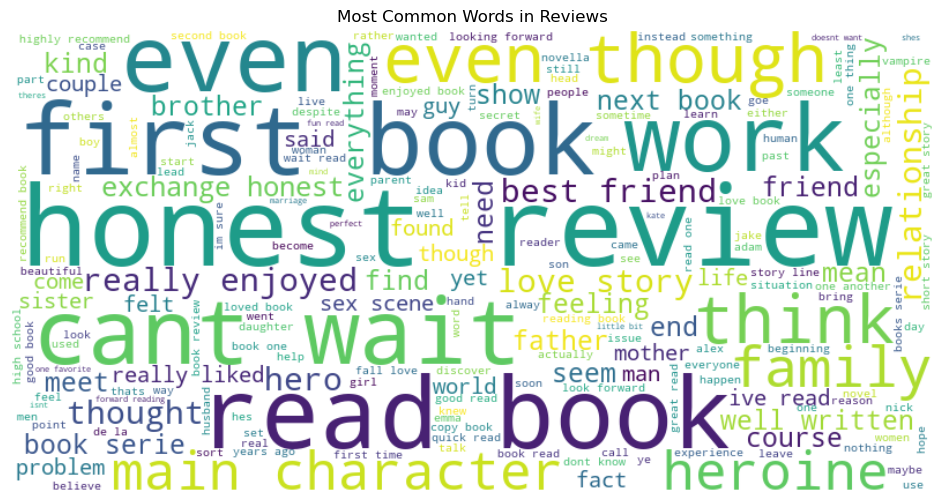

In [45]:
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(" ".join(revs_books["clean_review"]))

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most Common Words in Reviews")
plt.show()